# Credal Sets with Unknown Validity

In [22]:
import sys
import os
import pickle
root_path = os.path.abspath('..')
sys.path.append(root_path)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from src.BPS import *
from src.helper import is_in_convex_hull_lp_batch_robust

In [23]:
methods = ["BPS_no_calib", "BPS_cond_cvg_satisfaction", "BPS_cond_cvg_satisfaction_zero", "BPS_mean_cond_cvg", "BPS_marg_cvg", "APS_no_calib", "APS_cond_cvg_satisfaction", "APS_cond_cvg_satisfaction_zero", "APS_mean_cond_cvg", "APS_marg_cvg"]
dataset = "cifar10"
model = "destercke"
model_seed_str = "3"
gamma = 0.4
alpha_cp_str = "0.1"
cond_cvg_thr = 0.9

methods_in_paper = [r"BPS $(1-\alpha)$", "Calibrated BPS with first-order", "Calibrated BPS with zero-order", "BPS with mean conditional miscoverage risk", "BPS with marginal miscoverage risk", r"APS $(1-\alpha)$", "Calibrated APS with first-order", "Calibrated APS with zero-order", "APS with mean conditional miscoverage risk", "APS with marginal miscoverage risk"]

In [24]:
rows = []

for dataset in ["cifar10", "chaosnli", "qualitymri"]:
    if dataset == "cifar10":
        calib_size = 0.2
    elif dataset == "chaosnli":
        calib_size = 0.5
    elif dataset == "qualitymri":
        calib_size = 0.5
    for m, method in enumerate(methods):
        set_sizes = []
        cond_sat = []
        marginal_cvg = []
        with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, str(gamma), "predictions.pkl"), 'rb') as f:
            predictions = pickle.load(f)
        val_per_seed = []
        for split_seed in range(10):
            calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"], predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
            if method[:3] == "BPS":
                with open(os.path.join(root_path, "all_sets", "unknown validity", dataset, model, model_seed_str, str(gamma), f"alphaCP_{alpha_cp_str}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                    results = pickle.load(f)
                sets = results["sets"][method]
            else:
                with open(os.path.join(root_path, "all_sets", "unknown validity", dataset, model, model_seed_str, str(gamma), f"APS_alphaCP_{alpha_cp_str}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                    results = pickle.load(f)
                sets = results["sets"][method]

            # these should be arrays across seeds
            set_sizes.append(np.mean(np.sum(sets, axis=1)))
            cond_sat.append(mean_cond_cvg_satisfaction(sets, test_true_probs, cond_cvg_thr-1e-3))
            marginal_cvg.append(marg_cvg(sets, test_labels))

        rows.append({
            "dataset": dataset,
            "method": methods_in_paper[m],
            "metric": "Set Size",
            "mean": np.array(set_sizes).mean(),
            "std": np.array(set_sizes).std()
        })

        rows.append({
            "dataset": dataset,
            "method": methods_in_paper[m],
            "metric": "Cond. Sat.",
            "mean": np.array(cond_sat).mean(),
            "std": np.array(cond_sat).std()
        })

        rows.append({
            "dataset": dataset,
            "method": methods_in_paper[m],
            "metric": "Marg. Cvg.",
            "mean": np.array(marginal_cvg).mean(),
            "std": np.array(marginal_cvg).std()
        })

df = pd.DataFrame(rows)

In [25]:
df["formatted"] = df.apply(
    lambda r: f"{r['mean']:.2f} $\\pm$ {r['std']:.2f}",
    axis=1
)

In [26]:
table = df.pivot_table(
    index="method",
    columns=["dataset", "metric"],
    values="formatted",
    aggfunc="first"
)

In [27]:
metric_order = ["Cond. Sat.", "Marg. Cvg.", "Set Size"]
dataset_order = ["cifar10", "chaosnli", "qualitymri"]

# Reindex the MultiIndex columns
table = table.reindex(
    columns=pd.MultiIndex.from_product([dataset_order, metric_order])
)

In [28]:
table

cifar10                   \
                                                 Cond. Sat.       Marg. Cvg.   
method                                                                         
APS $(1-\alpha)$                            0.48 $\pm$ 0.00  0.89 $\pm$ 0.00   
APS with marginal miscoverage risk          0.56 $\pm$ 0.09  0.90 $\pm$ 0.00   
APS with mean conditional miscoverage risk  0.80 $\pm$ 0.01  0.93 $\pm$ 0.00   
BPS $(1-\alpha)$                            0.52 $\pm$ 0.00  0.90 $\pm$ 0.00   
BPS with marginal miscoverage risk          0.34 $\pm$ 0.17  0.90 $\pm$ 0.00   
BPS with mean conditional miscoverage risk  0.75 $\pm$ 0.02  0.93 $\pm$ 0.00   
Calibrated APS with first-order             0.90 $\pm$ 0.01  0.99 $\pm$ 0.00   
Calibrated APS with zero-order              0.48 $\pm$ 0.00  0.89 $\pm$ 0.00   
Calibrated BPS with first-order             0.90 $\pm$ 0.01  0.98 $\pm$ 0.00   
Calibrated BPS with zero-order              0.52 $\pm$ 0.00  0.90 $\pm$ 0.00   

                                                                    chaosnli  \
                                                   Set Size       Cond. Sat.   
method                                                                         
APS $(1-\alpha)$                            0.99 $\pm$ 0.00  0.44 $\pm$ 0.02   
APS with marginal miscoverage risk          1.01 $\pm$ 0.01  0.75 $\pm$ 0.03   
APS with mean conditional miscoverage risk  1.08 $\pm$ 0.01  0.74 $\pm$ 0.03   
BPS $(1-\alpha)$                            1.09 $\pm$ 0.00  0.61 $\pm$ 0.01   
BPS with marginal miscoverage risk          1.09 $\pm$ 0.01  0.71 $\pm$ 0.05   
BPS with mean conditional miscoverage risk  1.17 $\pm$ 0.01  0.70 $\pm$ 0.03   
Calibrated APS with first-order             1.40 $\pm$ 0.07  0.91 $\pm$ 0.01   
Calibrated APS with zero-order              0.99 $\pm$ 0.00  0.89 $\pm$ 0.02   
Calibrated BPS with first-order             1.45 $\pm$ 0.05  0.91 $\pm$ 0.02   
Calibrated BPS with zero-order              1.09 $\pm$ 0.00  0.90 $\pm$ 0.01   

                                                                              \
                                                 Marg. Cvg.         Set Size   
method                                                                         
APS $(1-\alpha)$                            0.84 $\pm$ 0.01  1.77 $\pm$ 0.01   
APS with marginal miscoverage risk          0.91 $\pm$ 0.01  2.06 $\pm$ 0.05   
APS with mean conditional miscoverage risk  0.90 $\pm$ 0.01  2.03 $\pm$ 0.03   
BPS $(1-\alpha)$                            0.89 $\pm$ 0.01  2.00 $\pm$ 0.02   
BPS with marginal miscoverage risk          0.91 $\pm$ 0.02  2.09 $\pm$ 0.05   
BPS with mean conditional miscoverage risk  0.90 $\pm$ 0.01  2.08 $\pm$ 0.03   
Calibrated APS with first-order             0.95 $\pm$ 0.01  2.39 $\pm$ 0.03   
Calibrated APS with zero-order              0.94 $\pm$ 0.01  2.31 $\pm$ 0.04   
Calibrated BPS with first-order             0.95 $\pm$ 0.01  2.40 $\pm$ 0.04   
Calibrated BPS with zero-order              0.95 $\pm$ 0.01  2.35 $\pm$ 0.04   

                                                 qualitymri                   \
                                                 Cond. Sat.       Marg. Cvg.   
method                                                                         
APS $(1-\alpha)$                            0.17 $\pm$ 0.06  0.76 $\pm$ 0.03   
APS with marginal miscoverage risk          0.63 $\pm$ 0.11  0.93 $\pm$ 0.03   
APS with mean conditional miscoverage risk  0.83 $\pm$ 0.05  0.97 $\pm$ 0.02   
BPS $(1-\alpha)$                            0.33 $\pm$ 0.05  0.81 $\pm$ 0.02   
BPS with marginal miscoverage risk          0.66 $\pm$ 0.09  0.93 $\pm$ 0.03   
BPS with mean conditional miscoverage risk  0.83 $\pm$ 0.05  0.97 $\pm$ 0.01   
Calibrated APS with first-order             0.94 $\pm$ 0.03  0.99 $\pm$ 0.01   
Calibrated APS with zero-order              0.73 $\pm$ 0.12  0.96 $\pm$ 0.03   
Calibrated BPS with first-order             0.94 

In [21]:
latex_table = table.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True
)

print(latex_table)

\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{cifar10} & \multicolumn{3}{r}{chaosnli} & \multicolumn{3}{r}{qualitymri} \\
 & Cond. Sat. & Marg. Cvg. & Set Size & Cond. Sat. & Marg. Cvg. & Set Size & Cond. Sat. & Marg. Cvg. & Set Size \\
method &  &  &  &  &  &  &  &  &  \\
\midrule
APS $(1-\alpha)$ & 0.48 $\pm$ 0.00 & 0.89 $\pm$ 0.00 & 0.99 $\pm$ 0.00 & 0.44 $\pm$ 0.02 & 0.84 $\pm$ 0.01 & 1.77 $\pm$ 0.01 & 0.17 $\pm$ 0.06 & 0.76 $\pm$ 0.03 & 1.24 $\pm$ 0.04 \\
APS with marginal miscoverage risk & 0.56 $\pm$ 0.09 & 0.90 $\pm$ 0.00 & 1.01 $\pm$ 0.01 & 0.75 $\pm$ 0.03 & 0.91 $\pm$ 0.01 & 2.06 $\pm$ 0.05 & 0.63 $\pm$ 0.11 & 0.93 $\pm$ 0.03 & 1.70 $\pm$ 0.09 \\
APS with mean conditional miscoverage risk & 0.80 $\pm$ 0.01 & 0.93 $\pm$ 0.00 & 1.08 $\pm$ 0.01 & 0.74 $\pm$ 0.03 & 0.90 $\pm$ 0.01 & 2.03 $\pm$ 0.03 & 0.83 $\pm$ 0.05 & 0.97 $\pm$ 0.02 & 1.85 $\pm$ 0.03 \\
BPS $(1-\alpha)$ & 0.52 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.09 $\pm$ 0.00 & 0.61 $\pm$ 0.01 & 0.89 $\pm$ 0.01 & 2.00 

In [13]:
predictions["outputs"].shape

(62, 12, 2)

# Partially Valid Credal Sets
Conformalized Credal Set Predictrors 


In [2]:
from src.helper import is_in_convex_hull_lp_batch_robust, tv

In [3]:
model = "RL_credal"
model_seed_str = "1"
gamma = 1.0
cond_cvg_thr = 0.9
epsilon_credals = [0.1, 0.2, 0.3]

In [4]:
rows = []

for dataset in ["cifar10", "chaosnli", "qualitymri"]:
    if dataset == "cifar10":
        calib_size = 0.2
    elif dataset == "chaosnli":
        calib_size = 0.5
    elif dataset == "qualitymri":
        calib_size = 0.5
    for epsilon in epsilon_credals:
        # credal_cvg = []
        credal_cvg_tv = []
        set_sizes = []
        cond_sat = []
        marginal_cvg = []
        with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, str(gamma), "predictions.pkl"), 'rb') as f:
            predictions = pickle.load(f)
        val_per_seed = []
        for split_seed in range(10):
            calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"], predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
            with open(os.path.join(root_path, "all_sets", "partially valid", dataset, model, model_seed_str, str(gamma), f"epsilonCredal_{epsilon}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                results = pickle.load(f)
            sets = results["sets_BPS"]
            # credal_cvg.append(np.mean(is_in_convex_hull_lp_batch_robust(test_true_probs, results["conformalized_credal_sets"], tol=1e-6)))
            credal_cvg_tv.append(np.mean(tv(test_credals.mean(axis=1), test_true_probs) <= results["credal_quantile"]+1e-5))
            # these should be arrays across seeds
            set_sizes.append(np.mean(np.sum(sets, axis=1)))
            cond_sat.append(mean_cond_cvg_satisfaction(sets, test_true_probs, cond_cvg_thr-1e-5))
            marginal_cvg.append(marg_cvg(sets, test_labels))

        
        # rows.append({
        #     "dataset": dataset,
        #     "epsilon": epsilon,
        #     "metric": "Credal Cvg",
        #     "mean": np.array(credal_cvg).mean(),
        #     "std": np.array(credal_cvg).std()
        # })
        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Credal Cvg.",
            "mean": np.array(credal_cvg_tv).mean(),
            "std": np.array(credal_cvg_tv).std()
        })
        
        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Set Size",
            "mean": np.array(set_sizes).mean(),
            "std": np.array(set_sizes).std()
        })


        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Cond. Sat.",
            "mean": np.array(cond_sat).mean(),
            "std": np.array(cond_sat).std()
        })

        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Marg. Cvg.",
            "mean": np.array(marginal_cvg).mean(),
            "std": np.array(marginal_cvg).std()
        })

df = pd.DataFrame(rows)

In [5]:
df["formatted"] = df.apply(
    lambda r: f"{r['mean']:.2f} $\\pm$ {r['std']:.2f}",
    axis=1
)

# ordered_metrics = ["Credal Cvg TV", "Cond Sat", "Marg Cvg", "Set Size"]

# Convert to categorical
# df['metric'] = pd.Categorical(df['metric'], categories=ordered_metrics, ordered=True)

table = df.pivot_table(
    index="epsilon",
    columns=["dataset", "metric"],
    values="formatted",
    aggfunc="first"
)

In [6]:
metric_order = ["Credal Cvg.", "Cond. Sat.", "Marg. Cvg.", "Set Size"]
dataset_order = ["cifar10", "chaosnli", "qualitymri"]

# Reindex the MultiIndex columns
table = table.reindex(
    columns=pd.MultiIndex.from_product([dataset_order, metric_order])
)

In [7]:
table

cifar10                                                     \
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size   
epsilon                                                                       
0.1      0.90 $\pm$ 0.01  0.97 $\pm$ 0.00  1.00 $\pm$ 0.00  6.55 $\pm$ 0.23   
0.2      0.80 $\pm$ 0.01  0.93 $\pm$ 0.01  0.99 $\pm$ 0.00  1.72 $\pm$ 0.43   
0.3      0.70 $\pm$ 0.01  0.84 $\pm$ 0.01  0.95 $\pm$ 0.01  1.18 $\pm$ 0.02   

                chaosnli                                                     \
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size   
epsilon                                                                       
0.1      0.89 $\pm$ 0.02  0.98 $\pm$ 0.01  0.92 $\pm$ 0.00  2.69 $\pm$ 0.00   
0.2      0.79 $\pm$ 0.03  0.95 $\pm$ 0.01  0.93 $\pm$ 0.00  2.67 $\pm$ 0.00   
0.3      0.70 $\pm$ 0.04  0.92 $\pm$ 0.01  0.94 $\pm$ 0.00  2.63 $\pm$ 0.01   

              qualitymri                                                     
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size  
epsilon                                                                      
0.1      0.90 $\pm$ 0.08  1.00 $\pm$ 0.00  0.90 $\pm$ 0.00  1.80 $\pm$ 0.00  
0.2      0.79 $\pm$ 0.08  1.00 $\pm$ 0.00  0.90 $\pm$ 0.00  1.80 $\pm$ 0.00  
0.3      0.71 $\pm$ 0.10  1.00 $\pm$ 0.00  0.90 $\pm$ 0.00  1.80 $\pm$ 0.00

In [8]:
latex_table = table.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True
)

print(latex_table)

\begin{tabular}{lllllllllllll}
\toprule
 & \multicolumn{4}{r}{cifar10} & \multicolumn{4}{r}{chaosnli} & \multicolumn{4}{r}{qualitymri} \\
 & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size \\
epsilon &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
0.100000 & 0.90 $\pm$ 0.01 & 0.97 $\pm$ 0.00 & 1.00 $\pm$ 0.00 & 6.55 $\pm$ 0.23 & 0.89 $\pm$ 0.02 & 0.98 $\pm$ 0.01 & 0.92 $\pm$ 0.00 & 2.69 $\pm$ 0.00 & 0.90 $\pm$ 0.08 & 1.00 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.80 $\pm$ 0.00 \\
0.200000 & 0.80 $\pm$ 0.01 & 0.93 $\pm$ 0.01 & 0.99 $\pm$ 0.00 & 1.72 $\pm$ 0.43 & 0.79 $\pm$ 0.03 & 0.95 $\pm$ 0.01 & 0.93 $\pm$ 0.00 & 2.67 $\pm$ 0.00 & 0.79 $\pm$ 0.08 & 1.00 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.80 $\pm$ 0.00 \\
0.300000 & 0.70 $\pm$ 0.01 & 0.84 $\pm$ 0.01 & 0.95 $\pm$ 0.01 & 1.18 $\pm$ 0.02 & 0.70 $\pm$ 0.04 & 0.92 $\pm$ 0.01 & 0.94 $\pm$ 0.00 & 2.63 $\pm$ 0.01 & 0.71 $\pm$ 0.10 & 1.00 $\pm$ 0.00 & 0.

In [9]:
rows = []

for dataset in ["cifar10", "chaosnli", "qualitymri"]:
    if dataset == "cifar10":
        calib_size = 0.2
    elif dataset == "chaosnli":
        calib_size = 0.5
    elif dataset == "qualitymri":
        calib_size = 0.5
    for epsilon in epsilon_credals:
        # credal_cvg = []
        credal_cvg_tv = []
        set_sizes = []
        cond_sat = []
        marginal_cvg = []
        with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, str(gamma), "predictions.pkl"), 'rb') as f:
            predictions = pickle.load(f)
        val_per_seed = []
        for split_seed in range(10):
            calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"], predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
            with open(os.path.join(root_path, "all_sets", "partially valid", dataset, model, model_seed_str, str(gamma), f"epsilonCredal_{epsilon}_cond_{cond_cvg_thr}_seed_{split_seed}.pkl"), 'rb') as f:
                results = pickle.load(f)
            sets = results["sets_APS"]
            # credal_cvg.append(np.mean(is_in_convex_hull_lp_batch_robust(test_true_probs, results["conformalized_credal_sets"], tol=1e-6)))
            credal_cvg_tv.append(np.mean(tv(test_credals.mean(axis=1), test_true_probs) <= results["credal_quantile"]+1e-5))
            # these should be arrays across seeds
            set_sizes.append(np.mean(np.sum(sets, axis=1)))
            cond_sat.append(mean_cond_cvg_satisfaction(sets, test_true_probs, cond_cvg_thr-1e-5))
            marginal_cvg.append(marg_cvg(sets, test_labels))

        
        # rows.append({
        #     "dataset": dataset,
        #     "epsilon": epsilon,
        #     "metric": "Credal Cvg",
        #     "mean": np.array(credal_cvg).mean(),
        #     "std": np.array(credal_cvg).std()
        # })
        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Credal Cvg.",
            "mean": np.array(credal_cvg_tv).mean(),
            "std": np.array(credal_cvg_tv).std()
        })
        
        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Set Size",
            "mean": np.array(set_sizes).mean(),
            "std": np.array(set_sizes).std()
        })


        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Cond. Sat.",
            "mean": np.array(cond_sat).mean(),
            "std": np.array(cond_sat).std()
        })

        rows.append({
            "dataset": dataset,
            "epsilon": epsilon,
            "metric": "Marg. Cvg.",
            "mean": np.array(marginal_cvg).mean(),
            "std": np.array(marginal_cvg).std()
        })

df = pd.DataFrame(rows)

In [10]:
df["formatted"] = df.apply(
    lambda r: f"{r['mean']:.2f} $\\pm$ {r['std']:.2f}",
    axis=1
)

# ordered_metrics = ["Credal Cvg TV", "Cond Sat", "Marg Cvg", "Set Size"]

# Convert to categorical
# df['metric'] = pd.Categorical(df['metric'], categories=ordered_metrics, ordered=True)

table = df.pivot_table(
    index="epsilon",
    columns=["dataset", "metric"],
    values="formatted",
    aggfunc="first"
)
metric_order = ["Credal Cvg.", "Cond. Sat.", "Marg. Cvg.", "Set Size"]
dataset_order = ["cifar10", "chaosnli", "qualitymri"]

# Reindex the MultiIndex columns
table = table.reindex(
    columns=pd.MultiIndex.from_product([dataset_order, metric_order])
)
latex_table = table.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True
)

print(latex_table)


\begin{tabular}{lllllllllllll}
\toprule
 & \multicolumn{4}{r}{cifar10} & \multicolumn{4}{r}{chaosnli} & \multicolumn{4}{r}{qualitymri} \\
 & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size & Credal Cvg. & Cond. Sat. & Marg. Cvg. & Set Size \\
epsilon &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
0.100000 & 0.90 $\pm$ 0.01 & 0.53 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.05 $\pm$ 0.00 & 0.89 $\pm$ 0.02 & 0.56 $\pm$ 0.03 & 0.89 $\pm$ 0.01 & 1.89 $\pm$ 0.02 & 0.90 $\pm$ 0.08 & 0.11 $\pm$ 0.04 & 0.52 $\pm$ 0.04 & 1.14 $\pm$ 0.03 \\
0.200000 & 0.80 $\pm$ 0.01 & 0.53 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.05 $\pm$ 0.00 & 0.79 $\pm$ 0.03 & 0.56 $\pm$ 0.03 & 0.89 $\pm$ 0.01 & 1.89 $\pm$ 0.02 & 0.79 $\pm$ 0.08 & 0.11 $\pm$ 0.04 & 0.52 $\pm$ 0.04 & 1.14 $\pm$ 0.03 \\
0.300000 & 0.70 $\pm$ 0.01 & 0.53 $\pm$ 0.00 & 0.90 $\pm$ 0.00 & 1.05 $\pm$ 0.00 & 0.70 $\pm$ 0.04 & 0.56 $\pm$ 0.03 & 0.89 $\pm$ 0.01 & 1.89 $\pm$ 0.02 & 0.71 $\pm$ 0.10 & 0.11 $\pm$ 0.04 & 0.

In [11]:
table

cifar10                                                     \
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size   
epsilon                                                                       
0.1      0.90 $\pm$ 0.01  0.53 $\pm$ 0.00  0.90 $\pm$ 0.00  1.05 $\pm$ 0.00   
0.2      0.80 $\pm$ 0.01  0.53 $\pm$ 0.00  0.90 $\pm$ 0.00  1.05 $\pm$ 0.00   
0.3      0.70 $\pm$ 0.01  0.53 $\pm$ 0.00  0.90 $\pm$ 0.00  1.05 $\pm$ 0.00   

                chaosnli                                                     \
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size   
epsilon                                                                       
0.1      0.89 $\pm$ 0.02  0.56 $\pm$ 0.03  0.89 $\pm$ 0.01  1.89 $\pm$ 0.02   
0.2      0.79 $\pm$ 0.03  0.56 $\pm$ 0.03  0.89 $\pm$ 0.01  1.89 $\pm$ 0.02   
0.3      0.70 $\pm$ 0.04  0.56 $\pm$ 0.03  0.89 $\pm$ 0.01  1.89 $\pm$ 0.02   

              qualitymri                                                     
             Credal Cvg.       Cond. Sat.       Marg. Cvg.         Set Size  
epsilon                                                                      
0.1      0.90 $\pm$ 0.08  0.11 $\pm$ 0.04  0.52 $\pm$ 0.04  1.14 $\pm$ 0.03  
0.2      0.79 $\pm$ 0.08  0.11 $\pm$ 0.04  0.52 $\pm$ 0.04  1.14 $\pm$ 0.03  
0.3      0.71 $\pm$ 0.10  0.11 $\pm$ 0.04  0.52 $\pm$ 0.04  1.14 $\pm$ 0.03

In [177]:
import numpy as np

def generate_credal_data(n, m, k):
    # Vary alpha to get different sizes
    alphas = np.random.uniform(30, 40, size=n)
    
    Q_hats = np.zeros((n, m, k))
    true_ps = np.zeros((n, k))
    
    for i in range(n):
        # Sample m vertices for the convex hull
        vertices = np.random.dirichlet([alphas[i]] * k, size=m)
        Q_hats[i] = vertices
        
        # Sample true p from the convex hull
        weights = np.random.dirichlet([1.0] * m)
        true_ps[i] = weights @ vertices
        
    return Q_hats, true_ps

In [277]:
def measure_credal_sizes(Q_hats):
    """
    Q_hats: (n, m, k) array of vertices
    Returns: Array of diameters (size n)
    """
    n, m, k = Q_hats.shape
    diameters = np.zeros(n)
    
    for i in range(n):
        vertices = Q_hats[i] # (m, k)
        
        # Calculate all-to-all Euclidean distances between the m vertices
        # This is a proxy for the 'size' of the convex hull
        dist_matrix = np.linalg.norm(vertices[:, None, :] - vertices[None, :, :], axis=-1)
        diameters[i] = np.max(dist_matrix)
        
    return diameters

In [278]:
np.random.dirichlet([1.0] * 4)

array([0.06874332, 0.57980764, 0.14258127, 0.20886777])

(array([ 81., 236., 181., 151., 121., 118.,  61.,  33.,  16.,   2.]),
 array([0.12284492, 0.21696361, 0.31108229, 0.40520097, 0.49931965,
        0.59343833, 0.68755702, 0.7816757 , 0.87579438, 0.96991306,
        1.06403174]),
 <BarContainer object of 10 artists>)

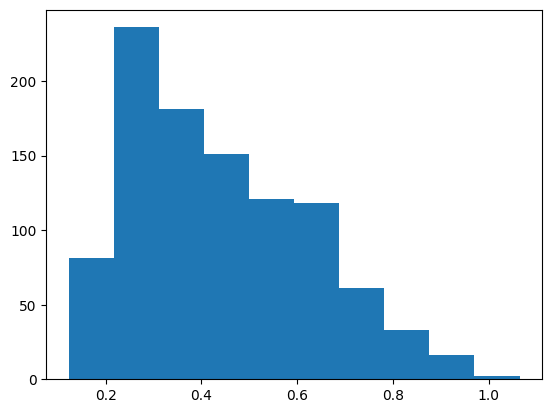

In [280]:
plt.hist(measure_credal_sizes(credal_sets))

100%|██████████| 1000/1000 [00:01<00:00, 903.33it/s]


(array([  9.,   8.,  23.,  41.,  62.,  99., 178., 156., 192., 232.]),
 array([1.91277249, 2.17149524, 2.43021799, 2.68894074, 2.9476635 ,
        3.20638625, 3.465109  , 3.72383175, 3.9825545 , 4.24127725,
        4.5       ]),
 <BarContainer object of 10 artists>)

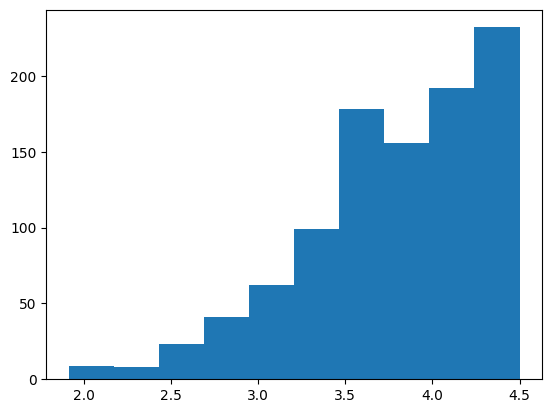

In [282]:
plt.hist(set_sizes)

In [260]:
set_sizes.mean()

np.float64(3.1963952246973695)

# Illustration for valid credal sets

issue: the credal sets are generated with all boundries 
their credal coverage is not 100%
fix it

In [ ]:
import sys
import os
import torch
import pickle
# Add root folder path to sys.path
root_path = os.path.abspath('..')
sys.path.append(root_path)
from tqdm import tqdm 
from torch.distributions import Dirichlet
from src.helper import get_tv_elementary_extreme_points_batch



torch.manual_seed(1)
n = 500 #number of instances
K = 3 #number of classes
dir_alpha = torch.tensor(K*[1.0]) #unifor Dirichlet parameter
mean_probs = Dirichlet(dir_alpha).sample((n,)) #mean probabilities



def true_prob(prob, K, d_min, d_max, tol=1e-6): 
    """
    this function takes probability distribution and returns another one that has 
    a total variation distence in the range [d_min, d_max] with that
    
    """
    for _ in range(100000):
        dir_alpha = torch.tensor(K*[1.0]) 
        candidate_prob = Dirichlet(dir_alpha).sample()
        tv = 0.5 * (prob - candidate_prob).abs().sum() 
        if tv <= d_max + tol and tv >= d_min - tol:
            return candidate_prob, tv
    print("could not find any")
    return  prob, 0

#credal sets are defined as a total variation distance ball around mean_probs and the radius of d_credal
d_credal = [0.01, 0.05, 0.1, 0.2, 0.3]

all_data = {"mean_probs":mean_probs, "probs":{}, "true_probs":{}, "tv_mean_true":{}}

for d in d_credal:
    probs = get_tv_elementary_extreme_points_batch(mean_probs.numpy(), d)
    true_probs = []
    tv_mean_true = []
    for i  in tqdm(range(n)): 
        d_min = d*torch.rand(1)
        t_prob, tv_t_prob = true_prob(mean_probs[i], K, d_min=1e-6, d_max=d)
        tv_mean_true.append(tv_t_prob)
        true_probs.append(t_prob)
    true_probs = torch.stack(true_probs)
    tv_mean_true = torch.stack(tv_mean_true)
    all_data["probs"][d] = probs
    all_data["true_probs"][d] = true_probs
    all_data["tv_mean_true"][d] = tv_mean_true


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 3307.41it/s]


In [83]:
get_tv_elementary_extreme_points_batch(mean_probs.numpy()[0:1], 0.1)

array([[[0.61797551, 0.2448762 , 0.13714829],
        [0.61797551, 0.3448762 , 0.03714829],
        [0.41797551, 0.4448762 , 0.13714829],
        [0.51797551, 0.4448762 , 0.03714829],
        [0.41797551, 0.3448762 , 0.23714829],
        [0.51797551, 0.2448762 , 0.23714829]]])

In [82]:
mean_probs.numpy()[0]

array([0.5179755 , 0.3448762 , 0.13714829], dtype=float32)

In [93]:
def true_prob(prob, K, d_min, d_max, tol=1e-6): 
    """
    this function takes probability distribution and returns another one that has 
    a total variation distence in the range [d_min, d_max] with that
    
    """
    for _ in range(100000):
        dir_alpha = torch.tensor(K*[1.0]) 
        candidate_prob = Dirichlet(dir_alpha).sample()
        tv = 0.5 * (prob - candidate_prob).abs().sum() 
        if tv <= d_max + tol and tv >= d_min - tol:
            return candidate_prob, tv
    print("could not find any")
    return  prob, 0

In [135]:
torch.manual_seed(2026)
n = 500 #number of instances
K = 5 #number of classes
dir_alpha = torch.tensor(K*[1.0]) #unifor Dirichlet parameter
mean_probs = Dirichlet(dir_alpha).sample((n,)) #mean probabilities



d = 0.2
credal_sets = []
true_probs = []
tv_mean_true = []
for i  in tqdm(range(n)): 
    d_credal = 1e-3 + d*torch.rand(1)
    probs = get_tv_elementary_extreme_points_batch(mean_probs.numpy()[i:i+1], d_credal.numpy())
    t_prob, tv_t_prob = true_prob(mean_probs[i], K, d_min=1e-5, d_max=d_credal)
    credal_sets.append(probs)
    tv_mean_true.append(tv_t_prob)
    true_probs.append(t_prob)


  5%|▌         | 27/500 [00:01<00:30, 15.32it/s]

could not find any


  8%|▊         | 41/500 [00:22<06:55,  1.10it/s]

could not find any


 10%|█         | 50/500 [00:31<06:40,  1.12it/s]

...

could not find any


 43%|████▎     | 217/500 [03:16<03:53,  1.21it/s]

could not find any


 44%|████▍     | 221/500 [03:17<04:09,  1.12it/s]


KeyboardInterrupt: 

array([[0.68968046, 0.06815578, 0.24216375],
       [0.17004812, 0.46108422, 0.36886767],
       [0.54493994, 0.3434854 , 0.11157467],
       ...,
       [0.33979684, 0.12296154, 0.5372416 ],
       [0.5907384 , 0.10844285, 0.30081874],
       [0.3614856 , 0.25620672, 0.3823077 ]],
      shape=(500, 3), dtype=float32)

In [131]:
credal_cvg = is_in_convex_hull_lp_batch_robust(torch.stack(true_probs).numpy(), np.vstack(credal_sets), tol=1e-6)
sets = solve_b_in_batches(np.vstack(credal_sets), nominal_coverage, batch_size=100)
set_sizes = np.sum(sets, axis=1)
cond_coverage = cond_cvg(sets, torch.stack(true_probs).numpy())
cond_sat = cond_coverage >= nominal_coverage - 1e-6

100%|██████████| 51/51 [00:00<00:00, 847.58it/s]


In [132]:
np.mean(credal_cvg)

np.float64(1.0)

(array([14.,  6.,  6.,  9.,  7.,  2.,  3.,  2.,  1.,  1.]),
 array([0.90160212, 0.91063672, 0.91967132, 0.92870592, 0.93774053,
        0.94677513, 0.95580973, 0.96484433, 0.97387893, 0.98291353,
        0.99194813]),
 <BarContainer object of 10 artists>)

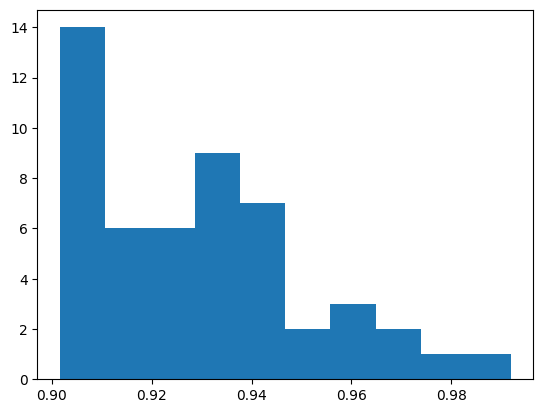

In [133]:
plt.hist(cond_coverage)

(array([1., 4., 4., 5., 4., 5., 3., 8., 8., 9.]),
 array([2.69265637, 2.85551256, 3.01836875, 3.18122494, 3.34408113,
        3.50693732, 3.66979351, 3.8326497 , 3.99550589, 4.15836208,
        4.32121827]),
 <BarContainer object of 10 artists>)

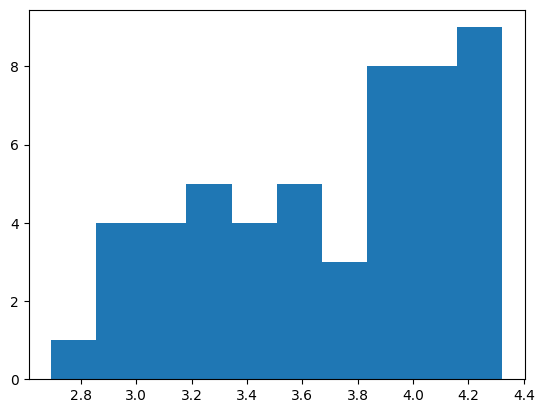

In [134]:
plt.hist(set_sizes)

In [ ]:
true_probs = torch.stack(true_probs)
tv_mean_true = torch.stack(tv_mean_true)
all_data["probs"][d] = probs
all_data["true_probs"][d] = true_probs
all_data["tv_mean_true"][d] = tv_mean_true

In [58]:
#############################
#save results
#############################
os.makedirs(os.path.join(root_path, "all_results", "illustration"), exist_ok=True) 
with open(os.path.join(root_path, "all_results", "illustration", "res.pkl"), 'wb') as f:
    pickle.dump(all_data, f)

In [76]:
for d in [0.01, 0.05, 0.1, 0.2, 0.3]:
    cvg = is_in_convex_hull_lp_batch_robust(all_data["true_probs"][d], all_data["probs"][d], tol=1e-6)
    print(f"d={d}: {np.mean(cvg):.4f}")

100%|██████████| 500/500 [00:00<00:00, 971.55it/s] 


d=0.01: 1.0000


100%|██████████| 500/500 [00:00<00:00, 1034.65it/s]


d=0.05: 1.0000


100%|██████████| 500/500 [00:00<00:00, 1033.07it/s]


d=0.1: 1.0000


100%|██████████| 500/500 [00:00<00:00, 1031.51it/s]


d=0.2: 1.0000


100%|██████████| 500/500 [00:00<00:00, 1031.77it/s]

d=0.3: 1.0000


In [3]:
import os
import pickle
from src.BPS import solve_b_in_batches, cond_cvg, mean_cond_cvg_satisfaction, marg_cvg

with open(os.path.join(root_path, "all_results", "illustration", "res.pkl"), 'rb') as f:
    all_data = pickle.load(f)

In [79]:
rows = []
d_credal = [0.01, 0.05, 0.1, 0.2]
nominal_coverage = 0.9
for d in d_credal:
    credal_cvg = is_in_convex_hull_lp_batch_robust(all_data["mean_probs"], all_data["probs"][d], tol=1e-6)
    sets = solve_b_in_batches(all_data["probs"][d], nominal_coverage, batch_size=100)
    set_sizes = np.sum(sets, axis=1)
    cond_coverage = cond_cvg(sets, all_data["true_probs"][d].numpy())
    cond_sat = cond_coverage >= nominal_coverage - 1e-6
    # marginal_cvg.append(marg_cvg(sets, test_labels))s)
    rows.append({
        "d": d,
        "metric": "Credal Cvg.",
        "mean": np.array(credal_cvg).mean(),
        "std": np.array(credal_cvg).std()
    })
    rows.append({
        "d": d,
        "metric": "Cond Sat.",
        "mean": np.array(cond_sat).mean(),
        "std": np.array(cond_sat).std()
    })
    rows.append({
        "d": d,
        "metric": "Set Size",
        "mean": np.mean(set_sizes),
        "std": np.std(set_sizes)
    })

df = pd.DataFrame(rows)

100%|██████████| 500/500 [00:00<00:00, 1040.32it/s]


,d,metric,mean,std
0,0.01,Credal Cvg.,1.000000,0.000000
1,0.01,Cond Sat.,1.000000,0.000000
2,0.01,Set Size,2.058577,0.410570
3,0.05,Credal Cvg.,1.000000,0.000000
4,0.05,Cond Sat.,1.000000,0.000000
5,0.05,Set Size,2.219644,0.357614
6,0.10,Credal Cvg.,1.000000,0.000000
7,0.10,Cond Sat.,1.000000,0.000000
8,0.10,Set Size,2.403721,0.248549
9,0.20,Credal Cvg.,1.000000,0.000000


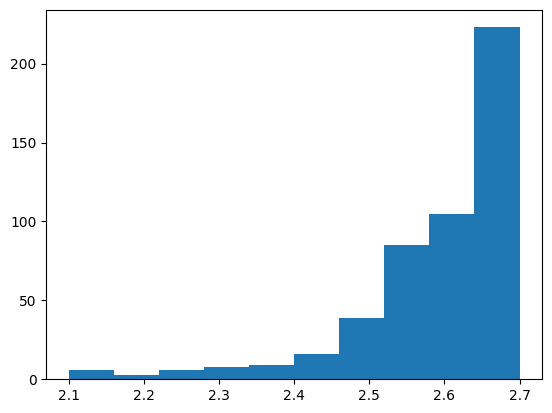

In [80]:
import matplotlib.pyplot as plt
plt.hist(set_sizes)

df

In [60]:
sets

array([[1.        , 1.        , 0.46566437],
       [1.        , 0.45578767, 1.        ],
       [1.        , 0.47825641, 1.        ],
       ...,
       [1.        , 1.        , 0.00530879],
       [1.        , 1.        , 0.0701311 ],
       [0.17131656, 1.        , 1.        ]], shape=(500, 3))

In [13]:
all_data["true_probs"]

{0.05: tensor([[0.8154, 0.1227, 0.0619],
         [0.0933, 0.3015, 0.6051],
         [0.0633, 0.8484, 0.0883],
         ...,
         [0.2228, 0.6467, 0.1305],
         [0.0699, 0.3536, 0.5765],
         [0.0662, 0.2391, 0.6946]]),
 0.1: tensor([[0.9039, 0.0477, 0.0484],
         [0.1699, 0.2805, 0.5496],
         [0.1347, 0.7772, 0.0881],
         ...,
         [0.1818, 0.6906, 0.1277],
         [0.0325, 0.2690, 0.6985],
         [0.0918, 0.3217, 0.5865]]),
 0.2: tensor([[0.6899, 0.3009, 0.0092],
         [0.1477, 0.1939, 0.6584],
         [0.2108, 0.7515, 0.0376],
         ...,
         [0.1754, 0.7821, 0.0425],
         [0.0850, 0.4303, 0.4847],
         [0.2429, 0.0809, 0.6761]]),
 0.3: tensor([[0.5350, 0.4296, 0.0354],
         [0.1984, 0.2130, 0.5886],
         [0.1615, 0.5133, 0.3253],
         ...,
         [0.1934, 0.7297, 0.0769],
         [0.3585, 0.2509, 0.3906],
         [0.2459, 0.0056, 0.7485]])}

In [14]:
for d in [0.05, 0.1, 0.2, 0.3]:
    cvg = is_in_convex_hull_lp_batch_robust(all_data["true_probs"][d], all_data["probs"][d])
    print(f"d={d}: {np.mean(cvg):.4f}")

100%|██████████| 1000/1000 [00:01<00:00, 953.65it/s]


d=0.05: 0.9700


100%|██████████| 1000/1000 [00:01<00:00, 965.95it/s]


d=0.1: 0.9400


100%|██████████| 1000/1000 [00:01<00:00, 982.29it/s]


d=0.2: 0.8600


100%|██████████| 1000/1000 [00:01<00:00, 987.49it/s]

d=0.3: 0.8180


In [ ]:
nominal_coverage = 0.9
d_credal = [0.05, 0.1, 0.2, 0.3]

sets = {"BPS":{}, "APS":{}}
for d in d_credal:
    sets["BPS"][d] = solve_b_in_batches(all_data["probs"][d], nominal_coverage, batch_size=100)
    sets["APS"][d] = solve_b_in_batches(all_data["mean_probs"].unsqueeze(axis=1), nominal_coverage, batch_size=100)
results = {"conditional cvg":{"BPS":{}, "APS":{}}, "set size":{"BPS":{}, "APS":{}}}
for d in d_credal:
    for approach in ["BPS", "APS"]:
        results["conditional cvg"][approach][d] = np.multiply(sets[approach][d], all_data["true_probs"][d]).sum(axis=1)
        results["set size"][approach][d] = sets[approach][d].sum(axis=1)

In [10]:
all_data.keys()

dict_keys(['mean_probs', 'probs', 'true_probs', 'tv_mean_true'])

In [ ]:
np.mean(np.sum(sets, axis=1))

In [24]:
dataset = "qualitymri"
model = "RL_credal"
model_seed_str = "3"
seed = int(model_seed_str)
gamma_str = "0.4"
gamma = float(gamma_str)
alpha_cp_str = "0.1"
alpha_cp = float(alpha_cp_str)
cnd_cvg_thr_str = "0.95"
cond_cvg_thr = float(cnd_cvg_thr_str)
split_seed_str = "0"
split_seed = int(split_seed_str)

nominal_coverage = 1 - alpha_cp
if dataset == "cifar10":
    calib_size = 0.2
elif dataset == "chaosnli":
    calib_size = 0.5
elif dataset == "qualitymri":
    calib_size = 0.5


with open(os.path.join(root_path, "all_credal_predictions", dataset, model, model_seed_str, gamma_str, "predictions.pkl"), 'rb') as f:
    predictions = pickle.load(f)


calib_credals, test_credals, calib_labels, test_labels, calib_true_probs, test_true_probs = train_test_split(predictions["outputs"].mean(axis=1, keepdims=True), predictions["targets_y"].astype(int), predictions["targets_p"], train_size=calib_size, random_state=2026+split_seed)
batch_size = min(100, test_credals.shape[0])
APS_no_calib = solve_b_in_batches(test_credals, cond_cvg_thr, batch_size=batch_size)


calibration_size = int(calib_size * len(predictions["outputs"]))
CP_target = np.ceil(nominal_coverage*(calibration_size+1))/calibration_size
# calibrate BPS with inverese risk = mean conditional satisfaction and first_order data
lambda_cond_cvg_satisfaction = lambda_optimizer(solve_b_in_batches, mean_cond_cvg_satisfaction,
                                    target=CP_target, tol=1e-5, lo=0.0, hi=1.0,
                                    set_predictor_kwargs={"credal_sets": calib_credals, "batch_size": batch_size}, 
                                    risk_kwargs={"true_dists": calib_true_probs, "desired_cond_cvg": cond_cvg_thr},
                                    return_sets=False)

In [19]:
test_credals.mean(axis=1, keepdims=True).shape

(31, 1, 2)

In [26]:
import sys
import os
import pickle
root_path = os.path.abspath('..')
sys.path.append(root_path)
import numpy as np
from src.BPS import *
from src.helper import one_hot
from sklearn.model_selection import train_test_split

In [ ]:
lambda_cond_cvg_satisfaction = lambda_optimizer(solve_b_in_batches, mean_cond_cvg_satisfaction,
                                    target=CP_target, tol=1e-5, lo=0.0, hi=1.0,
                                    set_predictor_kwargs={"credal_sets": calib_credals, "batch_size": batch_size}, 
                                    risk_kwargs={"true_dists": calib_true_probs, "desired_cond_cvg": cond_cvg_thr},
                                    return_sets=False)
APS_cond_cvg_satisfaction = solve_b_in_batches(test_credals, lambda_cond_cvg_satisfaction, batch_size=batch_size)

# calibrate BPS with inverese risk = mean conditional satisfaction and zero_order data
lambda_cond_cvg_satisfaction_zero = lambda_optimizer(solve_b_in_batches, mean_cond_cvg_satisfaction,
                                    target=CP_target, tol=1e-5, lo=0.0, hi=1.0,
                                    set_predictor_kwargs={"credal_sets": calib_credals, "batch_size": batch_size}, 
                                    risk_kwargs={"true_dists": one_hot(calib_labels, K=calib_true_probs.shape[1]), "desired_cond_cvg": cond_cvg_thr},
                                    return_sets=False)
APS_cond_cvg_satisfaction_zero = solve_b_in_batches(test_credals, lambda_cond_cvg_satisfaction_zero, batch_size=batch_size)

# calibrate BPS with inverese risk = mean conditional coverage and first_order data
lambda_mean_cond_cvg = lambda_optimizer(solve_b_in_batches, mean_cond_cvg,
                                    target=CP_target, tol=1e-5, lo=0.0, hi=1.0,
                                    set_predictor_kwargs={"credal_sets": calib_credals, "batch_size": batch_size}, 
                                    risk_kwargs={"true_dists": calib_true_probs},
                                    return_sets=False)
APS_mean_cond_cvg= solve_b_in_batches(test_credals, lambda_mean_cond_cvg, batch_size=batch_size)

# calibrate BPS with inverese risk = marginal coverage and zero_order data
lambda_marg_cvg = lambda_optimizer(solve_b_in_batches, marg_cvg,
                                    target=CP_target, tol=1e-5, lo=0.0, hi=1.0,
                                    set_predictor_kwargs={"credal_sets": calib_credals, "batch_size": batch_size}, 
                                    risk_kwargs={"labels": calib_labels},
                                    return_sets=False)
APS_marg_cvg= solve_b_in_batches(test_credals, lambda_marg_cvg, batch_size=batch_size)

: 

In [ ]:
print()